In [168]:
!pip install fg-data-profiling pandas numpy pingouin --quiet
!pip install matplotlib --quiet
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from data_profiling import ProfileReport
from google.colab import files
from google.colab import auth
import gspread
from google.auth import default
import plotly.graph_objs as go
import plotly.io as pio
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from google.cloud import bigquery
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats
import pingouin as pg
from IPython.display import HTML, display


!pip install --upgrade google-cloud-bigquery --quiet
auth.authenticate_user()

In [2]:
project_id = 'project-515019b4-2c9b-4866-a5c'
client = bigquery.Client(project=project_id)

query = """
    SELECT * FROM `project-515019b4-2c9b-4866-a5c.retail_sales_dataset.retail_sales_dataset`
  """

df = client.query(query).to_dataframe()

print(df.head(10))

  order_id order_date customer_id customer_name  age gender region  city  \
0     None       None        None          None  NaN   None   None  None   
1     None       None        None          None  NaN   None   None  None   
2     None       None        None          None  NaN   None   None  None   
3     None       None        None          None  NaN   None   None  None   
4     None       None        None          None  NaN   None   None  None   
5     None       None        None          None  NaN   None   None  None   
6     None       None        None          None  NaN   None   None  None   
7     None       None        None          None  NaN   None   None  None   
8     None       None        None          None  NaN   None   None  None   
9     None       None        None          None  NaN   None   None  None   

  product_category product_name  ...  unit_price  discount_pct  sales_amount  \
0             None         None  ...         NaN           NaN           NaN   
1  

In [3]:
profile = ProfileReport(df, title="Profiling Report",explorative=True)
profile.to_file('report.html')
files.download('report.html')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 21/21 [00:01<00:00, 17.96it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [4]:
df.shape

(4310, 21)

In [5]:
df.dtypes

,0
order_id,object
order_date,object
customer_id,object
customer_name,object
age,float64
gender,object
region,object
city,object
product_category,object
product_name,object


In [6]:
df.isnull().sum()

,0
order_id,30
order_date,30
customer_id,30
customer_name,30
age,160
gender,30
region,30
city,30
product_category,30
product_name,30


In [7]:
string_columns_to_process = [
    'customer_name', 'gender', 'region', 'city', 'product_category',
    'product_name', 'payment_method', 'order_status'
]

df[string_columns_to_process] = df[string_columns_to_process].astype(str).apply(lambda x: x.str.strip().str.lower())
df[string_columns_to_process] = df[string_columns_to_process].apply(lambda x: x.str.title())

In [8]:
missing = df.isnull().mean()*100
print(missing[missing>0].sort_values(ascending=False))

customer_satisfaction    8.770302
discount_pct             3.874710
age                      3.712297
quantity                 3.248260
days_to_ship             3.016241
order_date               0.696056
customer_id              0.696056
order_id                 0.696056
unit_price               0.696056
profit                   0.696056
sales_amount             0.696056
shipping_cost            0.696056
return_flag              0.696056
dtype: float64


In [9]:
n_dupes = df.duplicated().sum()
n_dupes

np.int64(109)

In [10]:
df[df.duplicated(keep=False)].sort_values(by=list(df.columns)).head(10)

,order_id,order_date,customer_id,customer_name,age,gender,region,city,product_category,product_name,...,unit_price,discount_pct,sales_amount,profit,shipping_cost,payment_method,customer_satisfaction,return_flag,order_status,days_to_ship
2090,ORD-00051,2020-01-20,CUST27973,Shreya Pillai,13.0,Male,South,Hyderabad,Beauty,Perfume,...,1952.59,0.14,6658.21,3867.94,38.17,Credit Card,1.0,False,Shipped,8.0
2096,ORD-00051,2020-01-20,CUST27973,Shreya Pillai,13.0,Male,South,Hyderabad,Beauty,Perfume,...,1952.59,0.14,6658.21,3867.94,38.17,Credit Card,1.0,False,Shipped,8.0
2922,ORD-00084,2020-02-03,CUST43984,Meera Kumar,58.0,Male,North,Ludhiana,Clothing,Kurta,...,1849.33,0.36,2115.12,453.68,31.92,Upi,5.0,False,Delivered,5.0
2925,ORD-00084,2020-02-03,CUST43984,Meera Kumar,58.0,Male,North,Ludhiana,Clothing,Kurta,...,1849.33,0.36,2115.12,453.68,31.92,Upi,5.0,False,Delivered,5.0
1311,ORD-00144,2020-02-27,CUST57714,Shreya Kumar,37.0,Female,South,Chennai,Furniture,Chair,...,32167.65,NaN,138458.15,39811.27,58.32,Cash On Delivery,5.0,False,Delivered,6.0
1313,ORD-00144,2020-02-27,CUST57714,Shreya Kumar,37.0,Female,South,Chennai,Furniture,Chair,...,32167.65,NaN,138458.15,39811.27,58.32,Cash On Delivery,5.0,False,Delivered,6.0
3039,ORD-00268,2020-04-27,CUST64785,Sunita Reddy,32.0,Female,West,Mumbai,Books,Cook Book,...,257.18,0.29,1452.88,604.81,60.36,Credit Card,1.0,False,Cancelled,5.0
3042,ORD-00268,2020-04-27,CUST64785,Sunita Reddy,32.0,Female,West,Mumbai,Books,Cook Book,...,257.18,0.29,1452.88,604.81,60.36,Credit Card,1.0,False,Cancelled,5.0
1065,ORD-00305,2020-05-12,CUST10300,Vikram Joshi,35.0,Other,East,Bhubaneswar,Sports,Yoga Mat,...,6852.57,0.19,30208.26,8215.56,100.86,Emi,5.0,False,Delivered,10.0
1066,ORD-00305,2020-05-12,CUST10300,Vikram Joshi,35.0,Other,East,Bhubaneswar,Sports,Yoga Mat,...,6852.57,0.19,30208.26,8215.56,100.86,Emi,5.0,False,Delivered,10.0


In [11]:
df=df.drop_duplicates()

In [12]:
df.shape

(4201, 21)

In [13]:
df.dropna(how='all', inplace=True)
df.drop(index=0, inplace=True)

/tmp/ipykernel_3477/893885066.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(how='all', inplace=True)
/tmp/ipykernel_3477/893885066.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(index=0, inplace=True)


In [14]:
# Συμπληρωνουμε τις na τιμες της στηλης age με τη διάμεσο των ηλικιών
df['age']=df['age'].fillna(df['age'].median())

# Συμπληρωνουμε τις na τιμες της στηλης quanity με τη διάμεσο των quanity
df['quantity']=df['quantity'].fillna(df['quantity'].median())

# Συμπληρωνουμε τις na τιμες της στηλης discount_pct με τη διάμεσο των discount_pct
df['discount_pct']=df['discount_pct'].fillna(df['discount_pct'].median())

# Συμπληρωνουμε τις na τιμες της στηλης customer_satisfaction με τη διάμεσο των customer_satisfaction
df['customer_satisfaction']=df['customer_satisfaction'].fillna(df['customer_satisfaction'].median())

# Συμπληρωνουμε τις na τιμες της στηλης days_to_ship με τη διάμεσο των days_to_ship
df['days_to_ship']=df['days_to_ship'].fillna(df['days_to_ship'].median())


/tmp/ipykernel_3477/1704465463.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['age']=df['age'].fillna(df['age'].median())
/tmp/ipykernel_3477/1704465463.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['quantity']=df['quantity'].fillna(df['quantity'].median())
/tmp/ipykernel_3477/1704465463.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://panda

In [15]:
df[df["discount_pct"].isna()]

,order_id,order_date,customer_id,customer_name,age,gender,region,city,product_category,product_name,...,unit_price,discount_pct,sales_amount,profit,shipping_cost,payment_method,customer_satisfaction,return_flag,order_status,days_to_ship


In [16]:
df['region'].unique()

array(['West', 'North', 'South', 'Central', 'East'], dtype=object)

In [17]:
for col in ['gender']:
    df[col]=df[col].str.strip().str.title()

gender_map = {
    'F' : 'Female',
    'M':'Male'
    }

df['gender']=df['gender'].map(gender_map).fillna(df['gender'])

/tmp/ipykernel_3477/1214858845.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col]=df[col].str.strip().str.title()
/tmp/ipykernel_3477/1214858845.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['gender']=df['gender'].map(gender_map).fillna(df['gender'])


In [18]:
# Διαχειρηση στηλων ωστε να ειναι στον σωστο τυπο δεδομενων

df['order_id'] = df['order_id'].astype("string")

df['order_date'] = pd.to_datetime(df['order_date'], format='mixed', errors='coerce')

df['customer_id'] = df['customer_id'].astype("string")

df['customer_name'] = df['customer_name'].astype("string")

df['age'] = pd.to_numeric(df['age'], errors='coerce').astype(int)

df['gender'] = df['gender'].astype('category')

df['region'] = df['region'].astype("category")

df['city'] = df['city'].astype("category")

df['product_category'] = df['product_category'].astype("category")

df['product_name'] = df['product_name'].astype("category")

df['quantity'] = pd.to_numeric(df['quantity'], errors='coerce').astype(int)

df['unit_price'] = pd.to_numeric(df['unit_price'], errors='coerce')

df['payment_method'] = df['payment_method'].astype("category")

df['customer_satisfaction'] = pd.to_numeric(df['customer_satisfaction'], errors='coerce').astype(int)

df['order_status'] = df['order_status'].astype("category")

df['days_to_ship'] = pd.to_numeric(df['days_to_ship'], errors='coerce').astype(int)






/tmp/ipykernel_3477/2095046718.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['order_id'] = df['order_id'].astype("string")
/tmp/ipykernel_3477/2095046718.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['order_date'] = pd.to_datetime(df['order_date'], format='mixed', errors='coerce')
/tmp/ipykernel_3477/2095046718.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the doc

In [19]:
df['order_year']=df['order_date'].dt.year
df['order_month']=df['order_date'].dt.month
df['order_day']=df['order_date'].dt.day_name()
df['month_name'] = df['order_date'].dt.month_name()

df['order_day'] = df['order_day'].astype("category")
df['month_name'] = df['month_name'].astype("category")




/tmp/ipykernel_3477/2850105010.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['order_year']=df['order_date'].dt.year
/tmp/ipykernel_3477/2850105010.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['order_month']=df['order_date'].dt.month
/tmp/ipykernel_3477/2850105010.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-doc

In [20]:
df.dtypes

,0
order_id,string[python]
order_date,datetime64[ns]
customer_id,string[python]
customer_name,string[python]
age,int64
gender,category
region,category
city,category
product_category,category
product_name,category


In [21]:
df.head(10)

,order_id,order_date,customer_id,customer_name,age,gender,region,city,product_category,product_name,...,shipping_cost,payment_method,customer_satisfaction,return_flag,order_status,days_to_ship,order_year,order_month,order_day,month_name
30,ORD-02076,2022-07-05,CUST05587,Priya Reddy,29,Other,West,Ahmedabad,Furniture,Bed Frame,...,54.47,Emi,3,False,Delivered,4,2022,7,Tuesday,July
31,ORD-03923,2024-08-20,CUST86711,Ritu Chatterjee,20,Female,West,Ahmedabad,Furniture,Bed Frame,...,54.52,Debit Card,2,False,Delivered,10,2024,8,Tuesday,August
32,ORD-00568,2020-09-10,CUST35377,Amit Reddy,49,Female,West,Ahmedabad,Furniture,Bed Frame,...,74.88,Debit Card,3,False,Delivered,2,2020,9,Thursday,September
33,ORD-00655,2020-10-21,CUST05466,Karan Kapoor,36,Female,West,Ahmedabad,Furniture,Bed Frame,...,49.07,Credit Card,3,False,Delivered,1,2020,10,Wednesday,October
34,ORD-00913,2021-02-15,CUST25496,Sanjay Pillai,15,Other,West,Ahmedabad,Furniture,Bed Frame,...,59.73,Credit Card,3,False,Delivered,6,2021,2,Monday,February
35,ORD-00937,2021-02-28,CUST46314,Nikhil Gupta,39,Other,West,Ahmedabad,Furniture,Bed Frame,...,49.26,Upi,4,False,Shipped,7,2021,2,Sunday,February
36,ORD-02108,2022-07-17,CUST78376,Shreya Das,44,Male,West,Ahmedabad,Furniture,Bed Frame,...,60.21,Upi,2,False,Delivered,8,2022,7,Sunday,July
37,ORD-03230,2023-10-29,CUST12331,Nikhil Singh,28,Other,West,Ahmedabad,Furniture,Bed Frame,...,51.84,Emi,2,False,Delivered,4,2023,10,Sunday,October
38,ORD-00708,2020-11-19,CUST56942,Deepa Kumar,40,Other,West,Ahmedabad,Books,Biography,...,72.21,Net Banking,4,False,Delivered,10,2020,11,Thursday,November
39,ORD-01141,2021-05-29,CUST04487,Meera Verma,34,Female,West,Ahmedabad,Books,Biography,...,30.99,Credit Card,3,False,Delivered,1,2021,5,Saturday,May


In [22]:
revenue_by_category = df.groupby('product_category')['sales_amount'].sum().sort_values(ascending=False)

# Μετατροπή σε DataFrame για καλύτερη εμφάνιση
df_category = revenue_by_category.reset_index()

print(df_category)

  product_category  sales_amount
0      Electronics  1.556426e+08
1        Furniture  5.670920e+07
2           Sports  3.168667e+07
3         Clothing  1.156374e+07
4           Beauty  3.881089e+06
5            Books  3.777514e+06
6        Groceries  1.009020e+06


/tmp/ipykernel_3477/2243463418.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  revenue_by_category = df.groupby('product_category')['sales_amount'].sum().sort_values(ascending=False)


In [23]:
# 1. Προετοιμασία δεδομένων
df_totals = df.groupby('product_category')['sales_amount'].sum().round(0).reset_index()

# 2. Δημιουργία Subplots
fig1 = make_subplots(
    rows=1, cols=2,
    specs=[[{"type": "table"}, {"type": "bar"}]],
    column_widths=[0.3, 0.7],  # Ο πίνακας λίγο πιο στενός από το γράφημα
    subplot_titles=("Συγκεντρωτικός Πίνακας", "Total Sales by Category")
    )

# 3. Προσθήκη Πίνακα (Table)
fig1.add_trace(
    go.Table(
        header=dict(values=["Κατηγορία", "Ποσό"], fill_color='paleturquoise', align='center',font=dict(size=20, color='black')),
        cells=dict(values=[df_totals['product_category'], df_totals['sales_amount'].apply(lambda x: f'{x:,.0f}')], fill_color='lavender', align='center',font=dict(size=14, color='black'),height=30)
    ),
    row=1, col=1
)

# 4. Προσθήκη του δικού σου Bar Chart Trace
# Χρησιμοποιούμε το trace που ήδη έχεις, απλά προσθέτουμε row=1, col=2
trace = go.Bar(
    x=df_totals['product_category'],
    y=df_totals['sales_amount'],
    text=df_totals['sales_amount'].apply(lambda x: f'{x:,.0f}'), # Changed format to .0f for whole numbers
    textposition="outside",
    textfont=dict(color="black", size=15),
    marker=dict(
        color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'],
        line=dict(color="black", width=1.5)
    )
)
# Add the bar chart trace to the second subplot
fig1.add_trace(trace, row=1, col=2)

fig1.update_layout(
    # Ρύθμιση τίτλου
    title={
        'text': "Business Analysis Dashboard",
        'y': 0.95,
        'x': 0.5,
        'xanchor': 'center',
        'yanchor': 'top',
        'font': dict(size=30, color="darkblue", family="Arial")
    },

    # Ρύθμιση των περιθωρίων (Margins) για να έχει "αέρα" ο τίτλος
    margin=dict(t=100, b=50, l=50, r=50),

    height=500,
    showlegend=False
)

fig1.update_annotations(font=dict(size=25))

fig1.show()

/tmp/ipykernel_3477/2205704412.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_totals = df.groupby('product_category')['sales_amount'].sum().round(0).reset_index()


In [24]:
df_totals_2 = df.groupby('product_name').agg({
    'sales_amount': 'sum',      # Άθροισμα για τα συνολικά έσοδα
    'quantity': 'sum',   # Άθροισμα για την ποσότητα
    'unit_price': 'mean'      # Μέσος όρος για την τιμή
}).round(0).sort_values(by='sales_amount', ascending=False).reset_index()

df_totals_2

/tmp/ipykernel_3477/1793890298.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,product_name,sales_amount,quantity,unit_price
0,Tablet,35826512.0,1470,44320.0
1,Laptop,26890531.0,661,44727.0
2,Headphones,25656395.0,622,42054.0
3,Smartwatch,24600859.0,601,41733.0
4,Camera,22118179.0,518,43834.0
5,Smartphone,20550102.0,504,44019.0
6,Tennis Racket,12236949.0,1535,8453.0
7,Desk,11565188.0,664,18780.0
8,Bed Frame,9936583.0,562,20121.0
9,Wardrobe,9439328.0,544,18291.0


In [25]:
fig2 = px.scatter(
    df_totals_2,
    x='unit_price',
    y='quantity',
    size='sales_amount',
    color='product_name',
    hover_name='product_name',
    title="Price vs. Quantity by Product (Bubble size by Total Sales)",
    height=600
)

fig2.update_layout(
    xaxis_title="Average Price",
    yaxis_title="Total Quantity Sold",
    showlegend=True
)

fig2.show()

In [26]:
df_daily = df.groupby('order_date')[['sales_amount']].sum().reset_index()

df_daily['sales_amount']=df_daily['sales_amount'].astype(int)
df_daily

,order_date,sales_amount
0,2020-01-01,15475
1,2020-01-02,61769
2,2020-01-03,95036
3,2020-01-04,117822
4,2020-01-05,2103
...,...,...
1586,2024-12-26,366957
1587,2024-12-27,344
1588,2024-12-28,191551
1589,2024-12-29,75488


In [27]:
fig3 = px.line(
    df_daily,
    x='order_date',
    y='sales_amount',
    title="Ανάλυση Πωλήσεων ανά Ημέρα (2020-2024)"
)

# Το Plotly διαχειρίζεται αυτόματα τις ημερομηνίες στον άξονα Χ
fig3.update_xaxes(
    rangeslider_visible=True, # Προσθέτει μια μπάρα zoom στο κάτω μέρος
    rangeselector=dict(
        buttons=list([
            dict(count=1, label="1m", step="month", stepmode="backward"),
            dict(count=6, label="6m", step="month", stepmode="backward"),
            dict(count=1, label="1y", step="year", stepmode="backward"),
            dict(step="all")
        ])
    )
)

fig3.show()

In [28]:
df_donut = df.groupby('month_name').agg({
    'sales_amount': 'sum',      # Άθροισμα για τα συνολικά έσοδα
    'quantity': 'sum',   # Άθροισμα για την ποσότητα
    'unit_price': 'mean'      # Μέσος όρος για την τιμή
}).round(0).sort_values(by='sales_amount', ascending=False).reset_index()

df_donut

/tmp/ipykernel_3477/1501501341.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,month_name,sales_amount,quantity,unit_price
0,January,32867217.0,3819,10117.0
1,April,28589623.0,2845,10174.0
2,August,26909952.0,3145,10168.0
3,July,26895593.0,3050,10449.0
4,June,25003367.0,1786,12078.0
5,May,24254581.0,1986,10242.0
6,September,19387666.0,1816,11252.0
7,March,17921000.0,1806,10727.0
8,February,16549780.0,2867,10672.0
9,October,15993399.0,1935,11123.0


In [113]:
pie_values1 = df_donut['sales_amount']
max_val = max(pie_values1)
pull_list = [0.1 if v == max_val else 0 for v in pie_values1]

fig4 = go.Figure(data=[go.Pie(
    labels=df_donut['month_name'],
    values=df_donut['sales_amount'],
    pull=pull_list,
    hole=.6, # <--- Αυτή είναι η παράμετρος που το κάνει Donut!
    marker=dict(colors=px.colors.qualitative.Plotly)
)])

fig4.update_layout(
    title="Sales Distribution",
    annotations=[dict(text=' ', x=0.5, y=0.5, font_size=20, showarrow=False)]
)

fig4.show()

In [30]:
df_donut2 = df.groupby('order_day').agg({
    'sales_amount': 'sum',      # Άθροισμα για τα συνολικά έσοδα
    'quantity': 'sum',   # Άθροισμα για την ποσότητα
    'unit_price': 'mean'      # Μέσος όρος για την τιμή
}).round(0).sort_values(by='sales_amount', ascending=False).reset_index()


df_donut2

/tmp/ipykernel_3477/2459480315.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,order_day,sales_amount,quantity,unit_price
0,Saturday,51105438.0,4191,10815.0
1,Tuesday,42537776.0,6361,11081.0
2,Friday,41055576.0,4359,10443.0
3,Thursday,35482440.0,3386,11015.0
4,Monday,32597681.0,4191,10985.0
5,Sunday,31635513.0,4157,10956.0
6,Wednesday,29855382.0,4254,9596.0


In [112]:
pie_values = df_donut2['sales_amount']
max_val = max(pie_values)
pull_list = [0.1 if v == max_val else 0 for v in pie_values]

fig5 = go.Figure(data=[go.Pie(
    labels=df_donut2['order_day'],
    values=pie_values,
    hole=.6, # <--- Αυτή είναι η παράμετρος που το κάνει Donut!
    pull=pull_list,  # explode
    marker=dict(colors=px.colors.qualitative.Plotly)
)])

fig5.update_layout(
    title="Sales Distribution by Day of Week",
    annotations=[dict(text=' ', x=0.5, y=0.5, font_size=20, showarrow=False)]
)

fig5.show()

In [32]:
# 1. Υπολογισμός των 4 τιμών
total_revenue = df['sales_amount'].sum()
aov = df['sales_amount'].sum() / df['order_id'].nunique()
total_orders = df['order_id'].nunique()
total_items = df['quantity'].sum()

# 2. Δημιουργία πλέγματος (1 σειρά, 4 στήλες)
fig0 = make_subplots(
    rows=1, cols=4,
    specs=[[{"type": "indicator"}, {"type": "indicator"}, {"type": "indicator"}, {"type": "indicator"}]]
)

# 3. Προσθήκη των 4 καρτών
fig0.add_trace(go.Indicator(
    mode = "number", value = total_revenue,
    number = {'suffix': " €", 'font': {'size': 24, 'color': '#1B5E20', 'weight': 'bold'}},
    title = {"text": "Συνολικά Έσοδα", "font": {"size": 13, "color": "#555555"}}
), row=1, col=1)

fig0.add_trace(go.Indicator(
    mode = "number", value = aov,
    number = {'suffix': " €", 'font': {'size': 24, 'color': '#0D47A1', 'weight': 'bold'}},
    title = {"text": "Average Order Value", "font": {"size": 13, "color": "#555555"}}
), row=1, col=2)

fig0.add_trace(go.Indicator(
    mode = "number", value = total_orders,
    number = {'font': {'size': 24, 'color': '#E65100', 'weight': 'bold'}},
    title = {"text": "Total Orders", "font": {"size": 13, "color": "#555555"}}
), row=1, col=3)

fig0.add_trace(go.Indicator(
    mode = "number", value = total_items,
    number = {'font': {'size': 24, 'color': '#4A148C', 'weight': 'bold'}},
    title = {"text": "Total Items Sold", "font": {"size": 13, "color": "#555555"}}
), row=1, col=4)

# 4. Υπολογισμός και σχεδίαση των 4 κουτιών (Boxes)
# Χωρίζουμε το 0 έως 1 της οθόνης σε 4 ίσα μέρη με κενά ενδιάμεσα
fig0.update_layout(
    shapes=[
        # Κάρτα 1
        dict(type="rect", xref="paper", yref="paper", x0=0.00, y0=0.05, x1=0.23, y1=0.95,
             line=dict(color="#CCCCCC", width=1.5), fillcolor="#FAFAFA", layer="below"),
        # Κάρτα 2
        dict(type="rect", xref="paper", yref="paper", x0=0.25, y0=0.05, x1=0.48, y1=0.95,
             line=dict(color="#CCCCCC", width=1.5), fillcolor="#FAFAFA", layer="below"),
        # Κάρτα 3
        dict(type="rect", xref="paper", yref="paper", x0=0.52, y0=0.05, x1=0.75, y1=0.95,
             line=dict(color="#CCCCCC", width=1.5), fillcolor="#FAFAFA", layer="below"),
        # Κάρτα 4
        dict(type="rect", xref="paper", yref="paper", x0=0.77, y0=0.05, x1=1.00, y1=0.95,
             line=dict(color="#CCCCCC", width=1.5), fillcolor="#FAFAFA", layer="below")
    ]
)

# 5. Τελικές ρυθμίσεις
fig0.update_layout(
    height=140,
    margin=dict(t=15, b=15, l=10, r=10),
    template="plotly_white"
)

fig0.show()

In [33]:
# 1. Ομαδοποίηση ανά πελάτη και άθροισμα του total
top_customers = df.groupby('customer_name')['sales_amount'].sum().sort_values(ascending=False)

# 2. Κράτα μόνο τους πρώτους 10
top_10_customers = top_customers.head(10).reset_index()

print(top_10_customers)

      customer_name  sales_amount
0      Kavya Kapoor   17637214.13
1        Nisha Bhat    7961220.17
2     Ananya Pillai    3356592.02
3       Ritu Kapoor    2623475.02
4       Nisha Joshi    2360876.34
5      Meera Kapoor    2172910.76
6  Rohan Chatterjee    2144465.02
7       Rohan Mehta    2063836.76
8        Sanjay Rao    2060455.89
9         Amit Shah    1955359.66


In [74]:
fig6 = px.bar(top_10_customers, x='sales_amount', y='customer_name',
             orientation='h',
             title='Top 10 Πελάτες Βάσει Εσόδων',
             labels={'sales_amount': 'Συνολικά Έσοδα (€)', 'customer_name': 'Όνομα Πελάτη'},
             color='sales_amount', # Προσθέτει χρώμα βάσει ποσού
             color_continuous_scale='rainbow',
             text=top_10_customers['sales_amount'].apply(lambda x: f'{x:,.0f}')) # Display formatted sales amount

# Set text position to inside the bars
fig6.update_traces(textposition='inside')

# Αντιστροφή για να είναι ο #1 στην κορυφή
fig6.update_yaxes(categoryorder='total ascending')
fig6.show()

In [64]:
top_selling_products = df.groupby('product_name')['sales_amount'].sum().sort_values(ascending=False).head(10).reset_index()
top_selling_products['sales_amount']=top_selling_products['sales_amount'].astype(int).head(10)

top_selling_products

/tmp/ipykernel_3477/4088325457.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,product_name,sales_amount
0,Tablet,35826512
1,Laptop,26890530
2,Headphones,25656395
3,Smartwatch,24600859
4,Camera,22118178
5,Smartphone,20550101
6,Tennis Racket,12236948
7,Desk,11565187
8,Bed Frame,9936582
9,Wardrobe,9439328


In [70]:
fig9 = px.bar(top_selling_products, x='sales_amount', y='product_name',
             orientation='h',
             title='Top 10 Προιόντα Βάσει Εσόδων',
             labels={'sales_amount': 'Συνολικά Έσοδα (€)', 'product_name': 'Όνομα Προιόντος'},
             color='sales_amount', # Προσθέτει χρώμα βάσει ποσού
             color_continuous_scale='bluered',
             text=top_selling_products['sales_amount'].apply(lambda x: f'{x:,}')) # Display formatted sales amount

# Update traces to set text position and prevent clipping
fig9.update_traces(textposition='inside')

# Αντιστροφή για να είναι ο #1 στην κορυφή
fig9.update_yaxes(categoryorder='total ascending')
fig9.show()

In [35]:
sales_by_year = (df.groupby('order_year')['sales_amount'].sum().reset_index().sort_values('order_year'))

sales_by_year


,order_year,sales_amount
0,2020,41055272.24
1,2021,57646116.88
2,2022,50346117.36
3,2023,64530469.99
4,2024,50691828.07


In [36]:
fig7 = go.Figure()
fig7.add_trace(go.Scatter(
    x=sales_by_year['order_year'],
    y=sales_by_year['sales_amount'],
    mode='lines+markers',
    line=dict(color='gray'),   # η γραμμή μένει ένα ουδέτερο χρώμα
    marker=dict(
        size=10,
        color=sales_by_year['order_year'],   # χρώμα ανά έτος
        colorscale='Viridis',
        showscale=False   # εμφανίζει και το colorbar-legend
    ),
    name='Δεδομένα'
))

fig7.update_xaxes(dtick=1, tickformat="d")
fig7.update_layout(title="Ανάλυση Πωλήσεων για κάθε χρόνο")
fig7.show()

In [46]:
sales_by_region=(df.groupby('region')['sales_amount'].sum().reset_index().sort_values('sales_amount'))
sales_by_region['sales_amount']=sales_by_region['sales_amount'].astype(int).apply(lambda x: f'{x:,}')
sales_by_region

/tmp/ipykernel_3477/147610318.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,region,sales_amount
0,Central,"40,673,510"
4,West,"47,962,618"
1,East,"48,501,551"
2,North,"53,613,030"
3,South,"73,519,093"


In [48]:
# 2. Δημιουργία Subplots
fig8 = make_subplots(
    rows=1, cols=2,
    specs=[[{"type": "table"}, {"type": "bar"}]],
    column_widths=[0.3, 0.7],  # Ο πίνακας λίγο πιο στενός από το γράφημα
    subplot_titles=("Συγκεντρωτικός Πίνακας", "Total Sales by Region")
    )

# 3. Προσθήκη Πίνακα (Table)
fig8.add_trace(
    go.Table(
        header=dict(values=["Περιοχή", "Ποσό"], fill_color='paleturquoise', align='center',font=dict(size=20, color='black')),
        cells=dict(values=[sales_by_region['region'], sales_by_region['sales_amount']], fill_color='lavender', align='center',font=dict(size=14, color='black'),height=30)
    ),
    row=1, col=1
)

# 4. Προσθήκη του δικού σου Bar Chart Trace
# Χρησιμοποιούμε το trace που ήδη έχεις, απλά προσθέτουμε row=1, col=2
trace = go.Bar(
    x=sales_by_region['region'],
    y=sales_by_region['sales_amount'].str.replace(',','').astype(float), # Convert back to float for plotting
    text=sales_by_region['sales_amount'], # Use the already formatted string
    textposition="outside",
    textfont=dict(color="black", size=15),
    marker=dict(
        color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'],
        line=dict(color="black", width=1.5)
    )
)
# Add the bar chart trace to the second subplot
fig8.add_trace(trace, row=1, col=2)

fig8.update_layout(
    # Ρύθμιση τίτλου
    title={
        'text': "Business Analysis Dashboard",
        'y': 0.95,
        'x': 0.5,
        'xanchor': 'center',
        'yanchor': 'top',
        'font': dict(size=30, color="darkblue", family="Arial")
    },

    # Ρύθμιση των περιθωρίων (Margins) για να έχει "αέρα" ο τίτλος
    margin=dict(t=100, b=50, l=50, r=50),

    height=500,
    showlegend=False
)

fig8.update_annotations(font=dict(size=25))

fig8.show()

In [121]:
# Βλέπουμε οτι έχουμε μη-εγκυρες τιμές στη στήλη ηλικία, γιατι έχουμε αρνητικές τιμές, κάποιες τιμές σε ηλικίες κατω των 10 ετών και τιμές σε ηλικίες πάνω απο 100 χρονών.
# Θα αντικαταστήσουμε αυτές τις τιμές με τη διάμεσο των ηλικιών, αφού πρώτα ομως υπολογίσουμε την σωστή διάμεσο των ηλικιών μόνο απο τις έγκυρες τιμές.
valid_median = df.loc[(df['age'] >= 15) & (df['age'] <= 100), 'age'].median()
print(f"Διάμεσος (από έγκυρες τιμές): {valid_median}")

df.loc[(df['age'] < 15) | (df['age'] > 100), 'age'] = valid_median

bins = [0, 30, 45, 60, 100]
labels = ['18-30', '31-45', '46-60', '60+']

df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=True)

df['age_group'].value_counts()



sales_by_ages_group_sum = df.groupby('age_group')['sales_amount'].sum().reset_index()

sales_by_ages_group_mean = df.groupby('age_group')['sales_amount'].mean().reset_index()

Διάμεσος (από έγκυρες τιμές): 34.0


/tmp/ipykernel_3477/3158415906.py:11: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_3477/3158415906.py:17: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/tmp/ipykernel_3477/3158415906.py:19: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [126]:
pie_values1 = sales_by_ages_group_sum['sales_amount']
max_val1 = max(pie_values1)
pull_list1 = [0.1 if v == max_val1 else 0 for v in pie_values1]

pie_values2 = sales_by_ages_group_mean['sales_amount']
max_val2 = max(pie_values2)
pull_list2 = [0.1 if v == max_val2 else 0 for v in pie_values2]


fig9 = make_subplots(
    rows=1, cols=2,
    specs=[[{'type': 'domain'}, {'type': 'domain'}]],
    subplot_titles=('Άθροισμα Πωλήσεων', 'Μέσος Όρος Πώλησεων')
)

fig9.add_trace(go.Pie(labels=sales_by_ages_group_sum['age_group'], values=sales_by_ages_group_sum['sales_amount'],pull=pull_list1, hole=0.6), row=1, col=1)
fig9.add_trace(go.Pie(labels=sales_by_ages_group_mean['age_group'], values=sales_by_ages_group_mean['sales_amount'],pull=pull_list2, hole=0.6), row=1, col=2)

fig9.update_layout(title_text="Σύγκριση: Όγκος Πωλήσεων vs Μέσος Όρος Πωλήσεων ανα Ηλικιακή Ομάδα")
fig9.show()

# Προσοχη

Παρουσιάζουμε και τα δύο διαγράμματα μαζί για να δείξουμε οτι παρότι η ηλικιακή ομάδα 31-45 έχει το μεγαλύτερο άθροισμα πωλήσεων αυτό οφείλεται στο οτι η συγκεκριμένη ομάδα αποτελείται απο περισσότερα άτομα. Βλέποντας το δυο διάγραμμα που ομαδοποιεί τα ίδια ποσά αλλα αυτή την φορά με βάση τους μέσους όρους βλέπουμε οτι η διαφορά είναι πολύ μικρότερη. Οπότε ναι μεν η ηλικιακή ομάδα 31-45 αγοράζει συχνότερα, οι υπόλοιπες ηλικιακές ομάδες αγοράζουν ακριβότερα προιόντα με αποτέλεσμα η διαφορά τους να μην ειναι σημαντική.

Αργότερα, στο κεφάλαιο Hypothesis Testing, βλέπουμε οτι η διαφορά στους μέσους όρους δεν είναι στατιστικά σημαντική, άρα το συμπέρασμα είναι οτι η ηλικία δεν ειναι καθοριστικός παράγοντας όσον αφορά τον συνολικό όγκο πωλήσεων.

Παρόλα αυτά είναι σημαντικό να κρατήσουμε ως στοιχείο το οτι η ηλικία είναι σημαντικός παράγοντας ως προς τον όγκο παραγγελιω. Δηλ συνολικά μπορούμε να πούμε οτι οι ηλικιακή ομάδα 31-45 είναι οι καταναλωτές που αγοράζουν πιο συχνά.

In [139]:
volume_of_orders_by_age_group = df.groupby('age_group').size().reset_index(name='n_purchases')
volume_of_orders_by_age_group

/tmp/ipykernel_3477/2386672912.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,age_group,n_purchases
0,18-30,1351
1,31-45,2116
2,46-60,683
3,60+,50


In [142]:
pie_values = volume_of_orders_by_age_group['n_purchases']
max_val = max(pie_values)
pull_list = [0.1 if v == max_val else 0 for v in pie_values]

fig10 = go.Figure(data=[go.Pie(
    labels=volume_of_orders_by_age_group['age_group'],
    values=pie_values,
    hole=.6,
    pull=pull_list,
    marker=dict(colors=px.colors.qualitative.Plotly)
)])

fig10.update_layout(
    title="Volume of Sales by Age Group",
    annotations=[dict(text=' ', x=0.5, y=0.5, font_size=20, showarrow=False)]
)

fig10.show()

In [141]:
# Εξωγωγη των Dashboard σε ενιαιο Report
dashboards = [
    {"title": "Συνολικά Έσοδα", "fig": fig0},
    {"title": "Συνολικές Πωλήσεις ανά Κατηγορία", "fig": fig1},
    {"title": "Συσχέτιση Τιμής Πώλησης με Ποσότητα", "fig": fig2},
    {"title": "Ανάλυση Πωλήσεων σε διάστημα 5 χρόνων", "fig": fig3},
    {"title": "Ανάλυση Πωλήσεων ανά Μήνα", "fig": fig4},
    {"title": "Ανάλυση Πωλήσεων ανά Ημέρα της Εβδομάδας", "fig": fig5},
    {"title": "Οι πελάτες που αποφέρουν τα περισσότερα έσοδα", "fig": fig6},
    {"title": "Πωλήσεις ανα Χρόνο", "fig": fig7},
    {"title": "Πωλήσεις ανα Περιοχή", "fig": fig8},
    {"title": "Όγκος Πωλήσεων vs Μέσος Όρος Πωλήσεων ανα Ηλικιακή Ομάδα", "fig": fig9},
    {"title": "Αριθμός Παραγγελιών ανα Ηλικιακή Ομάδα", "fig": fig10}

    ]

# Δημιουργία του αρχείου HTML
with open("Final_Business_Report.html", "w", encoding='utf-8') as f:
    f.write("<html><head><meta charset='utf-8'><title>Business Report</title>")
    f.write("<style>body {font-family: Arial; margin: 40px;} h1 {color: #003366;}</style>")
    f.write("</head><body>")

    f.write("<h1>Αναφορά Πωλήσεων σε διάστημα 5 χρόνων</h1>")

    for item in dashboards:
        f.write(f"<h2>{item['title']}</h2>")
        # Ενσωμάτωση του κάθε Plotly graph
        f.write(item['fig'].to_html(full_html=False, include_plotlyjs='cdn'))

    f.write("</body></html>")

# **HYPOTHESIS TESTING**

So in the next section we will try to find out more about our dataset with hypothesis testing.

At first we will group our values **by gender** and we will fidn out if the difference is statistical significant. The problem is that we may see a difference in means of each group but without the hypothesis testing we cant be sure if that difference is important enough or big enough.

In [38]:
df_hypothesis_testing_by_gender=df.groupby('gender').agg({
    'gender': 'count',
    'sales_amount': 'mean'
})
df_hypothesis_testing_by_gender

/tmp/ipykernel_3477/1907063384.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,gender,sales_amount
gender,,
Female,1373,62501.739512
Male,1408,66041.022166
Other,1419,60231.964045


In [39]:
df_hypothesis_testing=df[['gender','sales_amount']]
df_hypothesis_testing

,gender,sales_amount
30,Other,262066.11
31,Female,123743.08
32,Female,185665.67
33,Female,208563.97
34,Other,55435.55
...,...,...
4304,Other,13731.31
4305,Other,40572.08
4306,Other,11448.72
4308,Other,22832.43


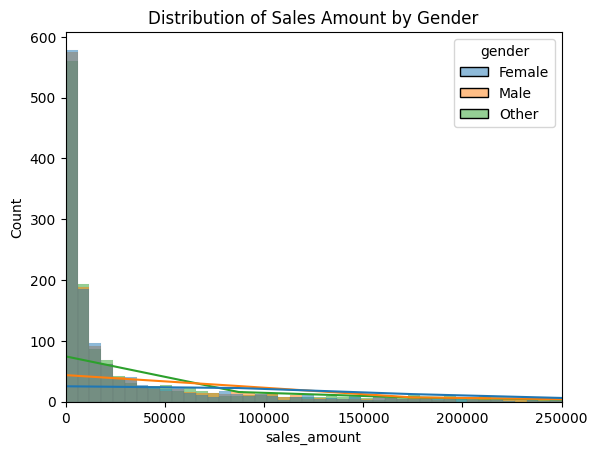

In [40]:
sns.histplot(data=df_hypothesis_testing, x='sales_amount', hue='gender', kde=True)
plt.xlim(0, 250000)
plt.title('Distribution of Sales Amount by Gender')
plt.show()

Ηδη βλέπουμε μια τεράστια ασσυμετρια στο ιστόγραμμα που μας δειχνει οτι το δειγμα δεν ειναι κανονικο. Παρόλα αυτά θα τρέξουμε και το τεστ Kruskal-Wallis για επιβεβαίωση.

In [41]:
pg.normality(df_hypothesis_testing, dv='sales_amount', group='gender')


,W,pval,normal
gender,,,
Other,0.480109,1.855505e-53,False
Female,0.061792,3.794319e-63,False
Male,0.195654,6.868515e-61,False


Οπότε όπως θα περιμένα τα αποτελέσματα και για τις 3 ομάδες είναι πολυ κοντά στο 0, οπότε το δείγμα μας δεν ειναι κανονικό.

Τότε θα εφαρμόσουμε μη-παραμετρικό τεστ και αφού έχουμε 3 ομάδες θα κάνουμε το Kruskal-Wallis

In [42]:
pg.kruskal(data=df_hypothesis_testing, dv='sales_amount', between='gender')


,Source,ddof1,H,p_unc
Kruskal,gender,2,2.184955,0.335384


Απο το τεστ Kruskal-Wallis παίρνουμε p-value=0.33 που σημαίνει οτι δεν μπορούμε να απορρίψουμε την μηδενική υπόθεση, άρα δεν υπάρχει στατιστικά σημαντική διαφορρά μεταξύ των 3 ομάδων.

Άρα παρότι αρχικά βλέπουμε οτι υπάρχει διαφορά στους μέσους όρους των ομάδων με βάση το φύλλο, απο το τεστ βγαίνει το συμπέρασμα οτι αυτή η διαφορά δεν είναι αρκετά σημαντική, οπότε μπορούμε να πούμε οτι το φύλλο δεν ειναι παράγοντας που διαφοροποιεί τη συμπεριφορά των καταναλωτών ως προς τις συνολικές αγορές.



---



**Ερώτημα** : Υπάρχει στατιστικά σημαντική διαφορά στις πωλήσεις ανάλογα με την ηλικία.


In [167]:
print("Normality Test:")
norm_test = pg.normality(df, dv='sales_amount', group='age_group')
display(norm_test)

display(HTML('<div style="height: 30px;"></div>'))

print("Kruskal - Wallis Test:")
kruskal_test = pg.kruskal(data=df, dv='sales_amount', between='age_group')
display(kruskal_test)

Normality Test:


,W,pval,normal
age_group,,,
18-30,0.520898,3.629736e-51,False
46-60,0.399583,1.448160e-42,False
31-45,0.086035,2.672208e-72,False
60+,0.563207,5.748555e-11,False


Kruskal - Wallis Test:


,Source,ddof1,H,p_unc
Kruskal,age_group,3,2.058904,0.560271


Οπότε βλέπουμε οτι η κατανομή των ηλικιών δεν είναι κανονική, οπότε τρέχουμε το test Kruskal - Wallis

Απο το τέστ παίρνουμε p=0.56, αρα δεν μπορούμε να απορρίψουμε την μηδενική υπόθεση. Οπότε δεν υπάρχει στατιστικά σημαντική διαφορά στις ηλικιακές ομάδες ως προς τις συνολικές πωλήσεις.



---



**Ερώτημα** : Υπάρχει στατιστικά σημαντική διαφορά στον αριθμό παραγγελιών ανάλογα με την ηλικία.

In [173]:
df_analyzed = df.groupby(['customer_id', 'age_group'])['order_id'].count().reset_index()
df_analyzed.rename(columns={'order_id': 'number_of_orders'}, inplace=True)
df_analyzed = df_analyzed[df_analyzed['number_of_orders'] > 0]
df_analyzed

/tmp/ipykernel_3477/2722771815.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,customer_id,age_group,number_of_orders
0,CUST00013,18-30,1
5,CUST00024,31-45,1
8,CUST00053,18-30,1
14,CUST00081,46-60,1
16,CUST00084,18-30,1
...,...,...,...
16428,CUST99942,18-30,1
16433,CUST99949,31-45,1
16437,CUST99964,31-45,1
16441,CUST99970,31-45,1


In [176]:
print("Normality Test:")
norm_test2 = pg.normality(data=df_analyzed, dv='number_of_orders', group='age_group')
display(norm_test2)

display(HTML('<div style="height: 30px;"></div>'))

print("Kruskal - Wallis Test:")
kruskal_test2 = pg.kruskal(data=df_analyzed, dv='number_of_orders', between='age_group')
display(kruskal_test2)

Normality Test:


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning:

scipy.stats.shapiro: Input data has range zero. The results may not be accurate.

/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning:

scipy.stats.shapiro: Input data has range zero. The results may not be accurate.



,W,pval,normal
age_group,,,
18-30,0.052995,7.890880e-63,False
31-45,0.086961,5.553385e-72,False
46-60,1.000000,1.000000e+00,True
60+,1.000000,1.000000e+00,True


Kruskal - Wallis Test:


,Source,ddof1,H,p_unc
Kruskal,age_group,3,11.441856,0.009562


Απο τα τεστ κανονικότητας βλέπουμε οτι οι κάποιες μεταβλητές ακολουθούν κανονική κατανομή και κάποιες άλλες οχι, οπότε και εδώ πάμε στο μη-παραμετρικό τεστ Kruskal Wallis.

Απο το τεστ βγαίνει οτι p=0.009, αρα απορρίπτουμε τη μηδενική υπόθεση, άρα υπάρχει στατιστικά σημαντική διαφορά μεταξύ των ομάδων.

Παρακάτω τρέχουμε τα pairwise tests για να δούμε μεταξύ ποιών ομάδων υπάρχει στατιστικά σημαντική διαφορά.

In [156]:
pg.pairwise_tests(data=df_analyzed,dv='number_of_orders',between='age_group',parametric=False,padjust='holm')

,Contrast,A,B,Paired,Parametric,U_val,alternative,p_unc,p_corr,p_adjust,hedges
0,age_group,18-30,31-45,False,False,6909723.5,two-sided,3.855001e-63,3.855001e-63,holm,-0.376586
1,age_group,18-30,46-60,False,False,9812249.5,two-sided,4.361234e-64,8.722468e-64,holm,0.380976
2,age_group,18-30,60+,False,False,11110849.0,two-sided,0.000000e+00,0.000000e+00,holm,0.918920
3,age_group,31-45,46-60,False,False,11354228.5,two-sided,5.201929e-237,2.080772e-236,holm,0.777698
4,age_group,31-45,60+,False,False,12647131.0,two-sided,0.000000e+00,0.000000e+00,holm,1.354840
5,age_group,46-60,60+,False,False,9755720.0,two-sided,1.625814e-132,4.877443e-132,holm,0.561013


Οπότε απο τις ζευγαρωτές συγκρίσεις συμπεραίνουμε οτι


*   Η ηλικιακή ομάδα 31-45 έχει τον μεγαλύτερο όγκο παραγγελιών
*   Δεύτερη καλύτερη είναι η ηλικιακή ομάδα 18-30
*   Ακολουθεί η ηλικιακή ομάδα 46-60
*   Το μικρότερο αριθμό πωλήσεων έχει ηλικιακή ομάδα 60+



